In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from pyspark.sql import SparkSession
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")
%matplotlib inline

In [17]:
file_path = '../data/raw/energy_consumption.csv'

df = pd.read_csv(file_path)

print(f"Size of the dataset: {df.shape[0]} row × {df.shape[1]} column\n")

print("======================= First five rows =======================")
print(df.head())

Size of the dataset: 2071728 row × 10 column

======================= First five rows =======================
                  MeasureItem              DateUTC   DateShort  \
0  Monthly Hourly Load Values  2019-01-01 00:00:00  2019-01-01   
1  Monthly Hourly Load Values  2019-01-01 01:00:00  2019-01-01   
2  Monthly Hourly Load Values  2019-01-01 02:00:00  2019-01-01   
3  Monthly Hourly Load Values  2019-01-01 03:00:00  2019-01-01   
4  Monthly Hourly Load Values  2019-01-01 04:00:00  2019-01-01   

              TimeFrom               TimeTo CountryCode  Cov_ratio   Value  \
0  1970-01-01 00:00:00  1970-01-01 01:00:00          AT        100  5852.5   
1  1970-01-01 01:00:00  1970-01-01 02:00:00          AT        100  5619.2   
2  1970-01-01 02:00:00  1970-01-01 03:00:00          AT        100  5323.9   
3  1970-01-01 03:00:00  1970-01-01 04:00:00          AT        100  5273.3   
4  1970-01-01 04:00:00  1970-01-01 05:00:00          AT        100  5439.0   

   Value_ScaleTo100  yea

In [18]:
print("======================= Data types =======================")
df.info()

print("======================= Missing data =======================")
print(df.isnull().sum())

======================= Data types =======================
<class 'pandas.DataFrame'>
RangeIndex: 2071728 entries, 0 to 2071727
Data columns (total 10 columns):
 #   Column            Dtype  
---  ------            -----  
 0   MeasureItem       str    
 1   DateUTC           str    
 2   DateShort         str    
 3   TimeFrom          str    
 4   TimeTo            str    
 5   CountryCode       str    
 6   Cov_ratio         int64  
 7   Value             float64
 8   Value_ScaleTo100  float64
 9   year              int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 158.1 MB
======================= Missing data =======================
MeasureItem         0
DateUTC             0
DateShort           0
TimeFrom            0
TimeTo              0
CountryCode         0
Cov_ratio           0
Value               0
Value_ScaleTo100    0
year                0
dtype: int64


In [19]:
# Convert column names to lowercase
df.columns = [col.lower().strip() for col in df.columns]
print("New column names:", df.columns.tolist(), "\n")

New column names: ['measureitem', 'dateutc', 'dateshort', 'timefrom', 'timeto', 'countrycode', 'cov_ratio', 'value', 'value_scaleto100', 'year'] 



In [20]:
columns_to_drop = ['measureitem', 'cov_ratio']
df = df.drop(columns=columns_to_drop, errors='ignore')

print(f" {len(columns_to_drop)} redundant columns dropped")
print(f"New columns: {df.columns.tolist()}\n")

 2 redundant columns dropped
New columns: ['dateutc', 'dateshort', 'timefrom', 'timeto', 'countrycode', 'value', 'value_scaleto100', 'year']



In [21]:
# Get only the hour, minute and second from timefrom and timeto
df['timefrom'] = pd.to_datetime(df['timefrom'], errors='coerce').dt.strftime('%H:%M:%S')
df['timeto']   = pd.to_datetime(df['timeto'],   errors='coerce').dt.strftime('%H:%M:%S')

print("timefrom and timeto columns cleaned")

print(df[['timefrom', 'timeto']].head())


timefrom and timeto columns cleaned
   timefrom    timeto
0  00:00:00  01:00:00
1  01:00:00  02:00:00
2  02:00:00  03:00:00
3  03:00:00  04:00:00
4  04:00:00  05:00:00


In [22]:
# Convert dateutc column to DateTime

df['dateutc'] = pd.to_datetime(df['dateutc'], utc=True, errors='coerce')
print(f"Date range: {df['dateutc'].min()}  ---  {df['dateutc'].max()}\n")

df = df.set_index('dateutc')

print("Data type after index:")
print(df.index.dtype)


Date range: 2019-01-01 00:00:00+00:00  ---  2025-09-30 23:00:00+00:00

Data type after index:
datetime64[us, UTC]


In [23]:
# Filter by country

selected_countries = ['HU', 'DE', 'FR', 'IT']

df_filtered = df[df['countrycode'].isin(selected_countries)].copy()

print(f"After filter: {df_filtered.shape[0]} rows remaining")

print("\n=== Statistics of the consumption by country ===")
stats = df_filtered.groupby('countrycode')['value'].describe().round(2)
print(stats)

After filter: 236572 rows remaining

=== Statistics of the consumption by country ===
               count      mean       std       min       25%       50%  \
countrycode                                                              
DE           59160.0  54663.23   9666.90  30908.88  46803.28  54517.36   
FR           59094.0  50628.98  10968.55  28744.00  42472.00  48728.00   
HU           59158.0   4923.82    779.29   2211.19   4330.31   4901.82   
IT           59160.0  32215.23   7282.55  15334.00  26001.00  31723.50   

                  75%       max  
countrycode                      
DE           62177.33  81077.46  
FR           57699.00  88174.00  
HU            5468.22   7394.76  
IT           38182.25  53824.00  


In [24]:
# Final data structure

print("=== Final columns ===")
print(df_filtered.columns.tolist())

print("\n=== First five rows after cleaning ===")
print(df_filtered.head())

=== Final columns ===
['dateshort', 'timefrom', 'timeto', 'countrycode', 'value', 'value_scaleto100', 'year']

=== First five rows after cleaning ===
                            dateshort  timefrom    timeto countrycode  \
dateutc                                                                 
2019-01-01 00:00:00+00:00  2019-01-01  00:00:00  01:00:00          DE   
2019-01-01 01:00:00+00:00  2019-01-01  01:00:00  02:00:00          DE   
2019-01-01 02:00:00+00:00  2019-01-01  02:00:00  03:00:00          DE   
2019-01-01 03:00:00+00:00  2019-01-01  03:00:00  04:00:00          DE   
2019-01-01 04:00:00+00:00  2019-01-01  04:00:00  05:00:00          DE   

                                value  value_scaleto100  year  
dateutc                                                        
2019-01-01 00:00:00+00:00  41653.9575        41653.9575  2019  
2019-01-01 01:00:00+00:00  40113.5800        40113.5800  2019  
2019-01-01 02:00:00+00:00  39312.9375        39312.9375  2019  
2019-01-01 03:00:0

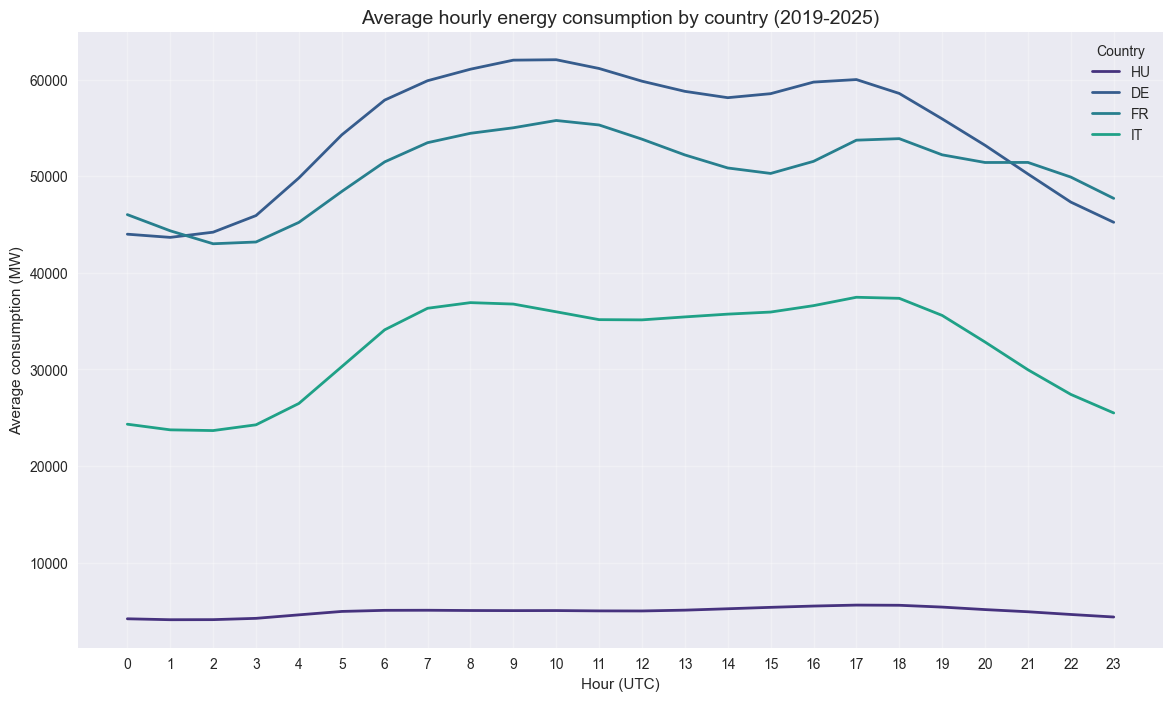

In [26]:
plt.figure(figsize=(14, 8))

for country in selected_countries:
    country_data = df_filtered[df_filtered['countrycode'] == country]
    hourly_avg = country_data.groupby(country_data.index.hour)['value'].mean()
    plt.plot(hourly_avg.index, hourly_avg.values, label=country, linewidth=2)

plt.title('Average hourly energy consumption by country (2019-2025)', fontsize=14)
plt.xlabel('Hour (UTC)')
plt.ylabel('Average consumption (MW)')
plt.legend(title='Country')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.show()